## Particle tracking: summary statistics 

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
import os
import matplotlib.pyplot as plt 
import numpy as np
import xarray as xr
from xgcm import Grid
import cmocean
import warnings
from datetime import datetime, timedelta
import matplotlib as mpl

In [3]:
%matplotlib inline
plt.rcParams['font.size'] = '12'
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
workingdir = '/g/data/jk72/mj0995'
os.chdir(workingdir) 

import functions as func

In [5]:
# import imp
# imp.reload(func)

In [6]:
savepath = os.path.join(workingdir, 'figures')

In [9]:
# load in adt datasets
adt_SEIR = xr.open_dataset('data/cmems_adt_MR.nc')
adt_DP = xr.open_dataset('data/cmems_DP.nc')

### Regional comparison

In [8]:
days = 10
region = 'DP'

if region == 'DP':
    lon0 = 298
elif region == 'SEIR':
    lon0 = 153

satgem_sel = xr.open_dataset(f'data/satgem_{region}_on_d_noisy.nc')

### Relationship between DSC magnitude and average $\nabla$T, speed and EKE along the particle trajectories

Pearsons corr: 0.531, p-value: 3.08e-13
Pearsons corr: 0.259, p-value: 0.000829
Pearsons corr: 0.351, p-value: 4.24e-06


/jobfs/145687208.gadi-pbs/ipykernel_51972/3820544192.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


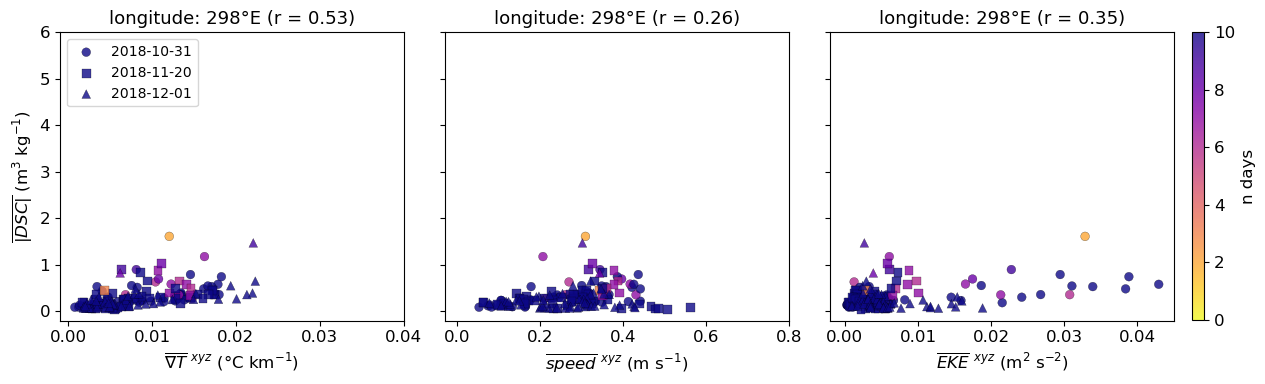

In [10]:
times = ['2018-10-31', '2018-11-20', '2018-12-01']
m = ['o', 's', '^']

fig, axs = plt.subplots(1, 3, sharey = True, figsize = (12,4))
ax = axs.flatten()

var = ['T_grad', 'speed', 'EKE']
labels = [r'$\overline{\nabla T}$ $^{xyz}$ (°C km$^{-1}$)', r'$\overline{speed}$ $^{xyz}$ (m s$^{-1}$)', r'$\overline{EKE}$ $^{xyz}$ (m$^{2}$ s$^{-2}$)']
for j in range(len(ax)):
    x_ct = []
    y_ct = []
    i = 0
    for t in times:
        ds = xr.open_dataset(f'summary_stats/{region}_MeridionalSection_{lon0}_{t}_{days}days.nc')

        x = ds[var[j]].mean('potential_density')
        y = abs(ds.DSC).mean('potential_density')
        c = ds.dsc_generation[:, 0]

        x_ct.append(x)
        y_ct.append(y)

        im = ax[j].scatter(x, y, marker = m[i], c = c, s= 40, cmap = 'plasma_r',
                         edgecolor = 'k', linewidths = 0.2,
                         vmin = 0, vmax = 10, alpha = 0.8)
        
        ds.close()
        i+=1
        
    corr, p_val = func.pearsons(np.asarray(x_ct).flatten(), np.asarray(y_ct).flatten())
    ax[j].set_title(f"longitude: {lon0}°E (r = {corr:.2f})", fontsize = 13)
    ax[j].set_xlabel(labels[j])

ax[0].set_ylim(-0.2, 6)
ax[0].set_xlim(-0.001, 0.04)
ax[1].set_xlim(-0.03, 0.8)
ax[2].set_xlim(-0.002, 0.045)
ax[0].set_ylabel('$\overline{|DSC|}$ (m$^{3}$ kg$^{-1}$)')
ax[0].legend(times, fontsize = 10, loc = 'upper left')

cax = fig.add_axes([1, 0.18, 0.01, 0.72])
plt.colorbar(im, cax =cax, label='n days')
plt.tight_layout()

In [15]:
# name = f'{region}_summary_stats_{lon0}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

### Cumulative distance travelled (meander vs upstream)

Text(0.5, 1.0, '298°E (meander)')

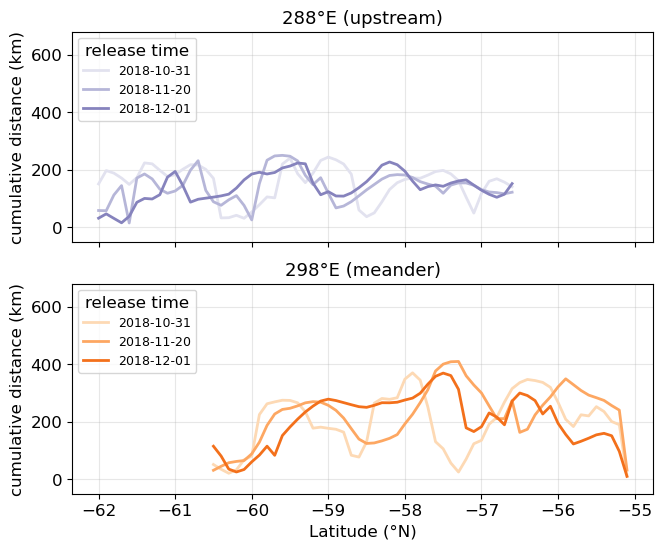

In [16]:
times = ['2018-10-31', '2018-11-20', '2018-12-01']

cols1 = plt.cm.Purples(np.linspace(0,1,len(times)*2))
cols2 = plt.cm.Oranges(np.linspace(0,1,len(times)*2))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, sharey = True, figsize = (7.5,6))

var = ['cum_dist']
i = 0
for t in times:
    ds = xr.open_dataset(f'summary_stats/{region}_MeridionalSection_{lon0-10}_{t}_{days}days.nc')
    ds.cum_dist.mean(dim = 'potential_density').plot(ax = ax1, c = cols1[i+1], linewidth = 2)
    
    ds = xr.open_dataset(f'summary_stats/{region}_MeridionalSection_{lon0}_{t}_{days}days.nc')
    ds.cum_dist.mean(dim = 'potential_density').plot(ax = ax2, c = cols2[i+1], linewidth = 2)
    
    i+=1
    
ax1.legend(times, title = 'release time', fontsize = 9, loc = 'upper left')
ax2.legend(times, title = 'release time', fontsize = 9, loc = 'upper left')
ax1.set_ylim(-50, 680)
ax1.grid(alpha = 0.3)
ax2.grid(alpha = 0.3)
ax1.set_ylabel('cumulative distance (km)')
ax2.set_ylabel('cumulative distance (km)')
ax1.set_xlabel('')
ax2.set_xlabel('Latitude (°N)')
ax1.set_title(f'{lon0-10}°E (upstream)', fontsize = 13)
ax2.set_title(f'{lon0}°E (meander)', fontsize = 13)

In [17]:
# name = f'{region}_summary_stats_cum_distance.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

### Diapycnal Spiciness Curvature (DSC) from reconstructed profiles

In [212]:
region = 'DP'
lon0 = 298
t = '2018-12-01'

In [213]:
ds = xr.open_dataset(f'/g/data/v45/mj0995/summary_stats/{region}_MeridionalSection_{lon0}_{t}_{days}days.nc')

Text(0.5, 1.0, 'longitude: 143°E')

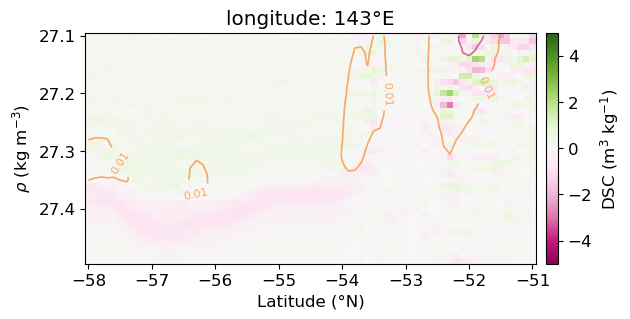

In [57]:
fig, ax = plt.subplots(figsize=(7, 3))
ds.DSC.plot(x = 'latitude', cmap = 'PiYG', vmin = -5, vmax = 5, 
         cbar_kwargs = dict(label = r'DSC (m$^{3}$ kg$^{-1}$)', pad = 0.02))

CS = ds.T_grad.plot.contour(x = 'latitude', cmap = 'plasma_r', levels = np.arange(0, 0.05, 0.01), linewidths = 1.2, alpha = 0.8)
plt.clabel(CS, np.arange(0, 0.04, 0.01), fontsize = 8)

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
plt.xlabel('Latitude (°N)')
plt.title(f'longitude: {lon0}°E')

## Regional maps

In [11]:
# region = 'DP'
# extent = [280, 304.5, -65, -50]

region = 'SEIR'
extent = [134, 166, -61, -49]

In [27]:
# start = '2018-09-21'
# end = '2018-12-01'
start = '2018-11-10'
end = '2018-11-20'

In [28]:
if region == 'DP':
    satgem_sel = xr.open_dataset(f'data/satgem_{region}_on_d_noisy.nc').sel(time = slice(start, end))
    ssh_insitu = adt_DP.sel(time = slice(start, end))
    figsize = (7,7)
    cb_ax = [0.92, 0.27, 0.02, 0.45]
    
elif region == 'SEIR':
    satgem_sel = xr.open_dataset(f'data/satgem_{region}_on_d_noisy.nc').sel(time = slice(start, end))
    ssh_insitu = adt_SEIR.sel(time = slice(start, end))
    figsize = (9,7)
    cb_ax = [0.92, 0.31, 0.015, 0.37]

In [29]:
t_sel = satgem_sel.temp.mean(dim = 'time')
t_grad = func.sshGrad(t_sel)

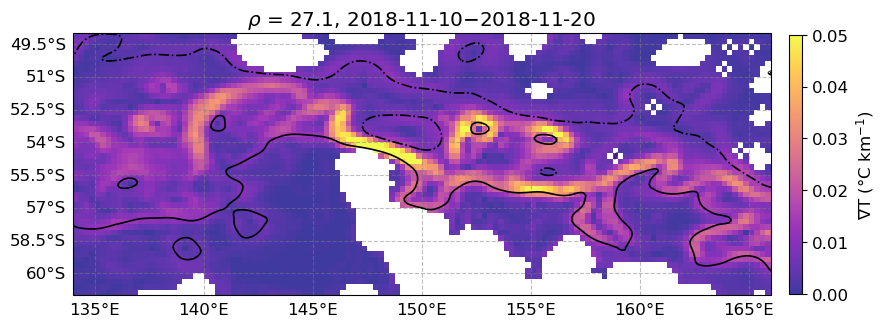

In [30]:
d = 27.1

fig = plt.figure(figsize=figsize)
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

func.map_properties(ax, slice(start, end), ssh_insitu)

im  = t_grad.sel(density = d, method = 'nearest').plot(cmap = 'plasma', 
                                                         vmin = 0, vmax = 0.05,
                                                         transform=ccrs.PlateCarree(), 
                                                         add_colorbar = False, 
                                                         alpha = 0.8, zorder = 0)

plt.title(r'$\rho$ ='+ f' {d}, ' + start + '$-$' + end)

cbar_ax = fig.add_axes(cb_ax) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'$\nabla$T (°C km$^{-1}$)')

In [31]:
u = satgem_sel.u_noise.sel(density = d, method = 'nearest')
v = satgem_sel.v_noise.sel(density = d, method = 'nearest')

mask = np.ma.masked_where(abs(u) > 1.5, abs(u))
u.data[mask.mask] = np.nan
mask = np.ma.masked_where(abs(v) > 1.5, abs(v))
v.data[mask.mask] = np.nan

eke = func.EKE(u, v, u.time[0].values, u.time[-1].values)

mask = np.ma.masked_where(eke > 0.1, eke)
eke.data[mask.mask] = np.nan

mean u and v between 2018-11-10 and 2018-11-20


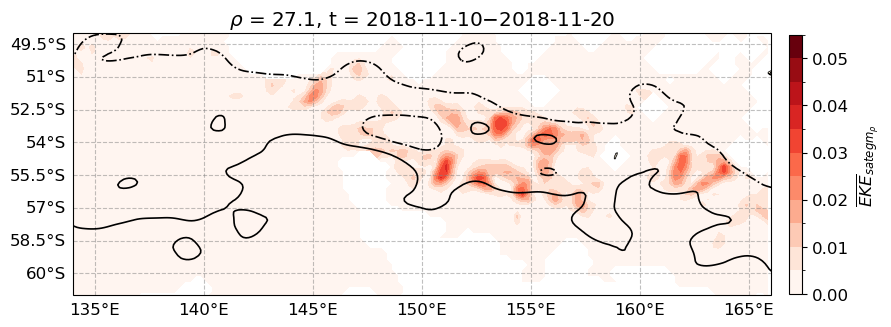

In [33]:
fig = plt.figure(figsize=figsize)
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

im = eke.mean(dim  = 'time').plot.contourf(levels = np.arange(0, 0.06, 0.005), 
                                           cmap = 'Reds', transform=ccrs.PlateCarree(), 
                                           add_colorbar = False)

func.map_properties(ax, slice(start, end), ssh_insitu)

plt.title(r'$\rho$ = ' + f'{d}, t = ' + start + '$-$' + end)

cbar_ax = fig.add_axes(cb_ax) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'$\overline{EKE}_{sategm_\rho}$')

### FTLEs

In [22]:
ftle_bw = xr.open_dataset(f'/g/data/jk72/mj0995/fsle/{region}/backward/{d}/FTLE_{region}_{d}.nc')
ftle_fw = xr.open_dataset(f'/g/data/jk72/mj0995/fsle/{region}/forward/{d}/FTLE_{region}_{d}.nc')

# mask = np.ma.masked_where(ftle_bw.lambda1 > -1e-10, ftle_bw.lambda1)
# ftle_bw.lambda1.data[mask.mask] = np.nan

In [23]:
start = '2018-11-10'
end = '2018-11-20'

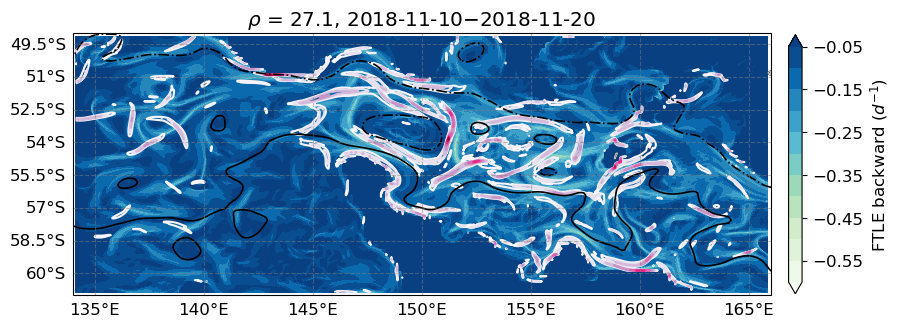

In [26]:
fig = plt.figure(figsize=(9, 7))
# fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

mean_FTLE_bw = ftle_bw.lambda1.sel(time = slice(start, end)).mean(dim = 'time').T
mean_FTLE_fw = ftle_fw.lambda1.sel(time = slice(start, end)).mean(dim = 'time').T
im = ax.contourf(ftle_bw.lon, ftle_bw.lat, mean_FTLE_bw, levels=np.arange(-0.6,0,0.05), cmap='GnBu', extend='both')
ax.contour(ftle_fw.lon, ftle_fw.lat, mean_FTLE_fw, levels=np.arange(0.25,0.7,0.05), cmap='PuRd', extend='both')

# mean adt contours
adt_SEIR.adt.sel(time = slice(start, end)).mean(dim = 'time').plot.contour(levels=[0.2], colors='k', linewidths = 1.2, linestyles = '-.', transform=ccrs.PlateCarree())
adt_SEIR.adt.sel(time = slice(start, end)).mean(dim = 'time').plot.contour(levels=[-0.65], colors='k', linewidths = 1.2, linestyles = '-', transform=ccrs.PlateCarree())

# lt = -55
# ax.axhline(y = lt, c = 'red')

ax.coastlines(color = 'silver', linewidth = 0.8, zorder = 12)
ax.add_feature(cfeature.LAND, edgecolor='k', zorder = 10)
gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.ylim(extent[2], extent[3])

plt.title(r'$\rho$'+ f' = {d}, ' + start + '$-$' + end)

cbar_ax = fig.add_axes([0.92, 0.31, 0.015, 0.37]) 
# cbar_ax = fig.add_axes([0.92, 0.27, 0.02, 0.45]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'FTLE backward ($d^{-1}$)')